In [ ]:
!pip install xgboost prophet google-cloud-bigquery pandas scikit-learn joblib matplotlib seaborn

In [ ]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from datetime import datetime

client = bigquery.Client.from_service_account_json('/content/fintech-intelligence-platform-14a6170252ba.json')
print("✅ Successfully connected to BigQuery!")

✅ Successfully connected to BigQuery!


In [ ]:
query_customers = """
SELECT
    customer_id,
    age,
    credit_score,
    balance,
    monthly_income,
    tenure_years,
    married,
    active_member,
    churn_label,
    customer_segment,
    loyalty_level,
    engagement_score,
    risk_score,
    risk_segment,
    cluster_group
FROM `fintech-intelligence-platform.fip_dwh_gold.dim_customers`
"""

df_customers = client.query(query_customers).to_dataframe()
print(f"✅ Read {len(df_customers):,} customers")
df_customers.head()

✅ Read 80,000 customers


,customer_id,age,credit_score,balance,monthly_income,tenure_years,married,active_member,churn_label,customer_segment,loyalty_level,engagement_score,risk_score,risk_segment,cluster_group
0,62486,45,653,23246130,33000000,0,1,False,True,Emerging,Bronze,7,0.3339,Low,1
1,73343,40,645,6675755,13000000,0,0,False,True,Mass,Bronze,7,0.3969,Low,1
2,14637,59,610,1384358,8000000,0,1,False,True,Mass,Bronze,7,0.4609,Medium,1
3,67924,78,710,90009095,28000000,0,2,False,False,Emerging,Bronze,7,0.2805,Low,1
4,29778,50,630,5734286,16000000,0,1,False,True,Emerging,Bronze,7,0.4078,Medium,1


In [ ]:
query_daily = """
SELECT
    txn_date,
    daily_revenue
FROM `fintech-intelligence-platform.fip_dwh_gold.fct_daily_metrics`
GROUP BY txn_date, daily_revenue
ORDER BY txn_date
"""

df_daily = client.query(query_daily).to_dataframe()
print(f"✅ Read {len(df_daily)} date rows")
df_daily.head()

✅ Read 366 date rows


,txn_date,daily_revenue
0,2023-01-01,2618566.57
1,2023-01-02,4987354.90
2,2023-01-03,4828380.70
3,2023-01-04,4947925.29
4,2023-01-05,4969903.35


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy customers data
df = df_customers.copy()

# Check for churn label distribution
print("Churn distribution:")
print(df['churn_label'].value_counts())
print(f"Churn rate: {df['churn_label'].mean():.2%}")

# Choose features for the model
feature_cols = [
    'age', 'credit_score', 'balance', 'monthly_income', 'tenure_years',
    'married', 'active_member', 'engagement_score', 'risk_score',
    'customer_segment', 'loyalty_level', 'risk_segment'
]

# Encode categorical rows
label_encoders = {}
for col in ['customer_segment', 'loyalty_level', 'risk_segment']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Prepare for X and Y
X = df[feature_cols]
y = df['churn_label'].astype(int)

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Dataset split:")
print(f"Train size: {len(X_train):,} samples")
print(f"Test size: {len(X_test):,} samples")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Churn distribution:
churn_label
False    65600
True     14400
Name: count, dtype: Int64
Churn rate: 18.00%
✅ Encoded customer_segment: {'Affluent': np.int64(0), 'Emerging': np.int64(1), 'Mass': np.int64(2), 'Priority': np.int64(3)}
✅ Encoded loyalty_level: {'Bronze': np.int64(0), 'Gold': np.int64(1), 'Silver': np.int64(2)}
✅ Encoded risk_segment: {'Low': np.int64(0), 'Medium': np.int64(1)}

📊 Dataset split:
Train size: 64,000 samples
Test size: 16,000 samples
Train churn rate: 18.00%
Test churn rate: 18.00%


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# Train XGBoost model
model_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("🚀 XGBoost model is being trained...")
model_xgb.fit(X_train, y_train)

# Forecast based on test sets
y_pred = model_xgb.predict(X_test)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

print("\n📊 Model Performance on Test Set:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred):.2%}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_pred_proba):.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📋 Confusion Matrix:")
print(f"True Negative:  {cm[0,0]:5,} | False Positive: {cm[0,1]:5,}")
print(f"False Negative: {cm[1,0]:5,} | True Positive:  {cm[1,1]:5,}")

🚀 XGBoost model is being trained...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:19:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📊 Model Performance on Test Set:
Accuracy:  83.84%
Precision: 60.15%
Recall:    30.24%
AUC-ROC:   85.59%

📋 Confusion Matrix:
True Negative:  12,543 | False Positive:   577
False Negative: 2,009 | True Positive:    871


🏆 Top 10 Features by Importance:
         feature  importance
   active_member    0.319435
      risk_score    0.265881
customer_segment    0.091899
  monthly_income    0.089893
    risk_segment    0.069209
         balance    0.042109
    tenure_years    0.035333
engagement_score    0.023674
   loyalty_level    0.019982
    credit_score    0.016762


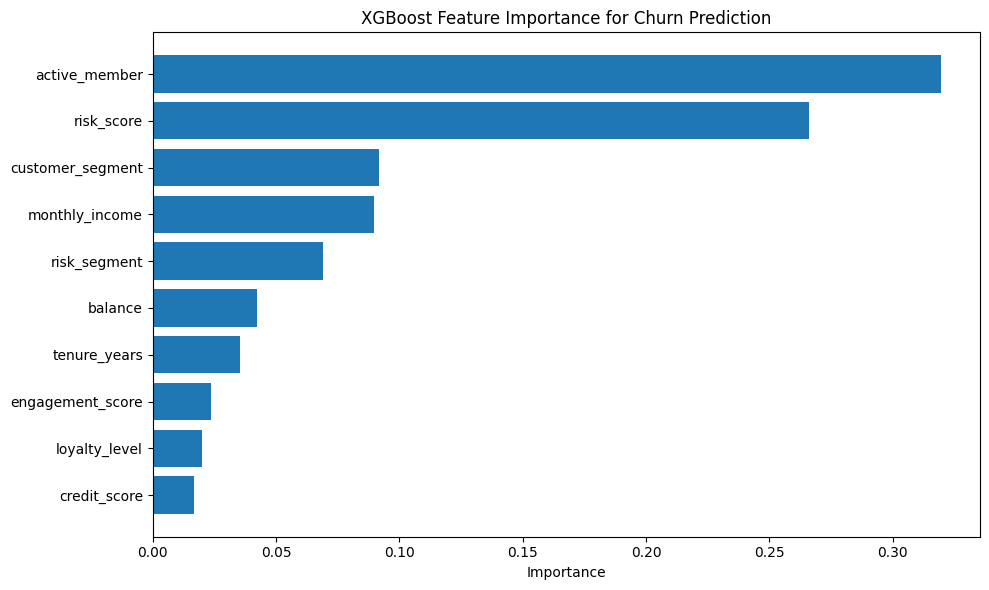

In [ ]:
# Take feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("🏆 Top 10 Features by Importance:")
print(feature_importance.head(10).to_string(index=False))

# Plot figures
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
!pip install pandas-gbq

from pandas_gbq import to_gbq
from datetime import datetime

# Add metadata
feature_importance['model_version'] = 'xgboost_v1'
feature_importance['created_at'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Overwrite to BigQuery (using client credentials)
to_gbq(
    feature_importance,
    destination_table='fip_dwh_gold.churn_feature_importance',
    project_id='fintech-intelligence-platform',
    if_exists='replace',
    credentials=client._credentials
)
print("✅ Feature importance saved to BigQuery")

100%|██████████| 1/1 [00:00<00:00, 8405.42it/s]

✅ Feature importance saved to BigQuery


In [ ]:
from pandas_gbq import to_gbq
from datetime import datetime

# Forecast the whole dataset
df_all = df_customers.copy()
for col in ['customer_segment', 'loyalty_level', 'risk_segment']:
    df_all[col] = label_encoders[col].transform(df_all[col].astype(str))

X_all = df_all[feature_cols]
churn_probabilities = model_xgb.predict_proba(X_all)[:, 1]

# Creating result table
churn_predictions = pd.DataFrame({
    'customer_id': df_customers['customer_id'],
    'churn_probability': churn_probabilities,
    'risk_level': pd.cut(churn_probabilities, bins=[0, 0.3, 0.7, 1.0],
                         labels=['Low', 'Medium', 'High']),
    'prediction_date': datetime.now().strftime('%Y-%m-%d')
})

# Overwrite to BigQuery
to_gbq(
    churn_predictions,
    destination_table='fip_dwh_gold.churn_predictions',
    project_id='fintech-intelligence-platform',
    if_exists='replace',
    credentials=client._credentials
)

print(f"✅ Churn predictions saved to BigQuery")
print(f"   - High risk (prob > 70%): {(churn_probabilities > 0.7).sum():,} customers")
print(f"   - Medium risk (30-70%): {((churn_probabilities > 0.3) & (churn_probabilities <= 0.7)).sum():,} customers")
print(f"   - Low risk (prob < 30%): {(churn_probabilities <= 0.3).sum():,} customers")

100%|██████████| 1/1 [00:00<00:00, 9962.72it/s]

✅ Churn predictions saved to BigQuery
   - High risk (prob > 70%): 1,493 customers
   - Medium risk (30-70%): 18,507 customers
   - Low risk (prob < 30%): 60,000 customers


📊 Dữ liệu từ 2023-01-01 00:00:00 đến 2024-01-01 00:00:00
Số ngày: 366


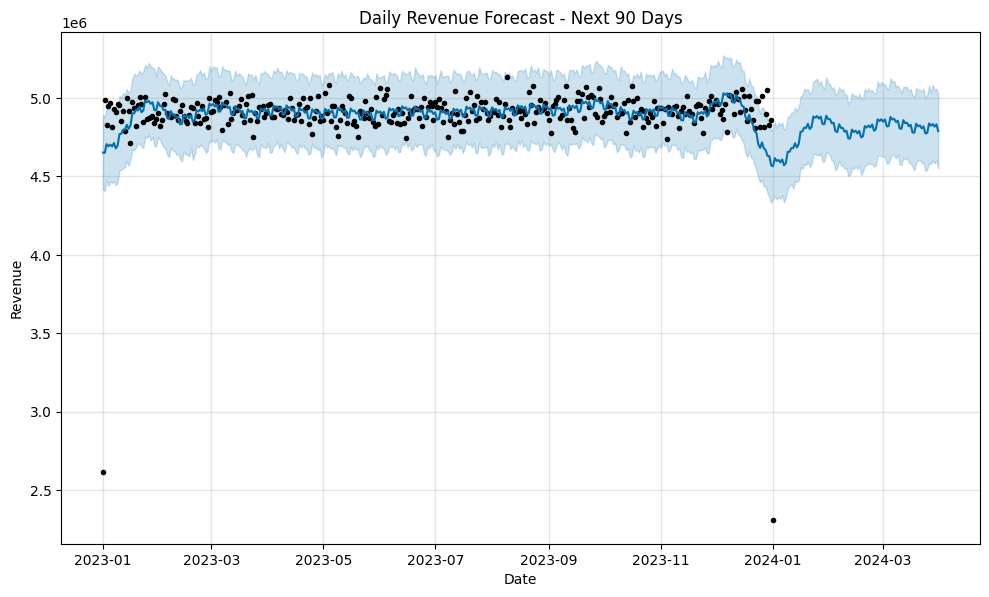


📈 Last 10 days forecast:
            ds          yhat    yhat_lower    yhat_upper
446 2024-03-22  4.806204e+06  4.583259e+06  5.042042e+06
447 2024-03-23  4.818770e+06  4.588810e+06  5.059434e+06
448 2024-03-24  4.773627e+06  4.533752e+06  4.995304e+06
449 2024-03-25  4.777649e+06  4.544764e+06  5.019372e+06
450 2024-03-26  4.837745e+06  4.581637e+06  5.078597e+06
451 2024-03-27  4.824565e+06  4.579232e+06  5.035891e+06
452 2024-03-28  4.833622e+06  4.603946e+06  5.084051e+06
453 2024-03-29  4.817441e+06  4.583134e+06  5.051728e+06
454 2024-03-30  4.832277e+06  4.602127e+06  5.059449e+06
455 2024-03-31  4.788845e+06  4.550739e+06  5.024631e+06


In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for Prophet (need 2 columns: ds, y)
df_forecast = df_daily[['txn_date', 'daily_revenue']].copy()
df_forecast.columns = ['ds', 'y']
df_forecast['ds'] = pd.to_datetime(df_forecast['ds'])

print(f"📊 Dữ liệu từ {df_forecast['ds'].min()} đến {df_forecast['ds'].max()}")
print(f"Số ngày: {len(df_forecast)}")

# Train Prophet model
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model_prophet.fit(df_forecast)

# Forecast in the next 90 days
future = model_prophet.make_future_dataframe(periods=90)
forecast = model_prophet.predict(future)

# Plot figures
fig = model_prophet.plot(forecast)
plt.title('Daily Revenue Forecast - Next 90 Days')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.show()

# View last 10 days forecast
print("\n📈 Last 10 days forecast:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

In [ ]:
from pandas_gbq import to_gbq

# Prepare forecast table for BigQuery
forecast_to_save = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_to_save.columns = ['forecast_date', 'revenue_forecast', 'revenue_lower', 'revenue_upper']
forecast_to_save['created_at'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# Overwrite to BigQuery
to_gbq(
    forecast_to_save,
    destination_table='fip_dwh_gold.forecast',
    project_id='fintech-intelligence-platform',
    if_exists='replace',
    credentials=client._credentials
)

print(f"✅ Forecast saved to BigQuery – {len(forecast_to_save)} rows")

100%|██████████| 1/1 [00:00<00:00, 9845.78it/s]

✅ Forecast saved to BigQuery – 456 rows
